# Data Cleaning with AI — Dirty Financial Transactions

## What is this notebook about?

Real-world datasets are almost never clean. They arrive with inconsistent labels, negative values
where only positives make sense, impossible dates, truncated text, and missing entries. Before any
analysis or machine learning, **data cleaning** is the essential first step.

This notebook walks through cleaning a synthetic but realistic **financial transactions dataset**
with 100,000 rows. 

Each section targets a specific type of dirty data, explains 
- *why* it is a problem, and
- shows *how* to fix it with pandas.

### Dataset columns

| Column | Type | Known Issues |
|---|---|---|
| `Transaction_ID` | String | Missing values |
| `Transaction_Date` | String → Date | Invalid dates (e.g. Feb 30), missing |
| `Customer_ID` | String | Missing values |
| `Product_Name` | String | Truncated names (e.g. `'Lap'`, `'He'`) |
| `Quantity` | Float | Negative values, outliers, missing |
| `Price` | String | Dollar signs, negative values, missing |
| `Payment_Method` | String | Inconsistent casing/spacing (`'pay pal'`, `'creditcard'`) |
| `Transaction_Status` | String | Mixed case (`'completed'`, `'Completed'`, `'complete'`), missing |

### Cleaning roadmap

| Step | Column | Problem | Fix |
|---|---|---|---|
| 1 | `Payment_Method` | Inconsistent labels | Normalize case + mapping |
| 2 | `Product_Name` | Truncated values | Manual mapping dictionary |
| 3 | `Quantity` | Negatives, outliers | `abs()`, outlier detection |
| 4 | `Price` | String type, negatives, missing | `to_numeric`, `abs()`, `round()` |
| 5 | `Transaction_Status` | Mixed case, missing | Normalize + drop NaN |
| 6 | All columns | Missing values | Drop or impute by column |
| 7 | `Transaction_Date` | Invalid/impossible dates | `pd.to_datetime(errors='coerce')` |
| 8 | All rows | Duplicates | `drop_duplicates()` |
| 9 | All columns | Wrong dtypes | Downcast to save memory |
| 10 | — | Save | Export to Parquet |


---
## Setup — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore

---
## Step 0 — Load and Explore the Dataset

Before cleaning anything, we explore the data to **understand what problems exist**.
Good data cleaning is diagnosis first, treatment second.

Key exploration questions:
- What do the first few rows look like?
- What are the data types and value ranges?
- How many unique values does each categorical column have?

In [4]:
# Load the dataset
df = pd.read_csv('4_dirty_financial_transactions.csv')  # local path
# df = pd.read_csv('/content/sample_data/dirty_financial_transactions.csv')

# Peek at the first 5 rows — already we can spot problems:
# negative Quantity, dollar signs in Price, mixed-case Payment_Method
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed


In [5]:
# Descriptive statistics for numeric columns
# Notice: Quantity min = -10 (impossible), Price is missing (it's dtype string)
df.describe()

,Quantity
count,94981.000000
mean,183.883914
std,299.292365
min,-10.000000
25%,-3.000000
50%,6.000000
75%,327.000000
max,1000.000000


In [6]:
# Descriptive statistics for categorical / object columns
# Notice: Payment_Method has 7 unique values when there should only be 3-4
# Transaction_Status has 5 unique values — likely case duplicates
df.describe(include=['object', 'category'])

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Price,Payment_Method,Transaction_Status
count,94982,95120,95122,100000,66503,100000,83321
unique,94040,1861,5000,46,65757,7,5
top,T57553,2023-13-01,C4347,Tablet,$814.62,Credit Card,Failed
freq,3,31834,37,18444,3,14433,16795


In [7]:
# Full list of columns — useful to confirm spelling before referencing them
print(df.columns)

Index(['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Product_Name',
       'Quantity', 'Price', 'Payment_Method', 'Transaction_Status'],
      dtype='object')


---
## Step 1 — Clean `Payment_Method`

### Problem
The same payment method appears under multiple spellings due to inconsistent data entry:
- `'pay pal'`, `'PayPal'`, `'PayPal '` → all mean PayPal
- `'creditcard'`, `'credit card'`, `'Credit Card'` → all mean Credit Card

If not fixed, groupby or pivot operations will treat these as different categories,
producing wrong counts and charts.

### Fix strategy
1. Strip leading/trailing whitespace → `.str.strip()`
2. Lowercase everything to make comparisons case-insensitive → `.str.lower()`
3. Map known variants to a canonical form → `.replace({...})`
4. Title-case the result for clean display → `.str.title()`

In [8]:
# Inspect all unique values — reveals the spelling variants
print(df['Payment_Method'].unique())

['pay pal' 'creditcard' 'credit card' 'PayPal' 'Cash' 'PayPal '
 'Credit Card']


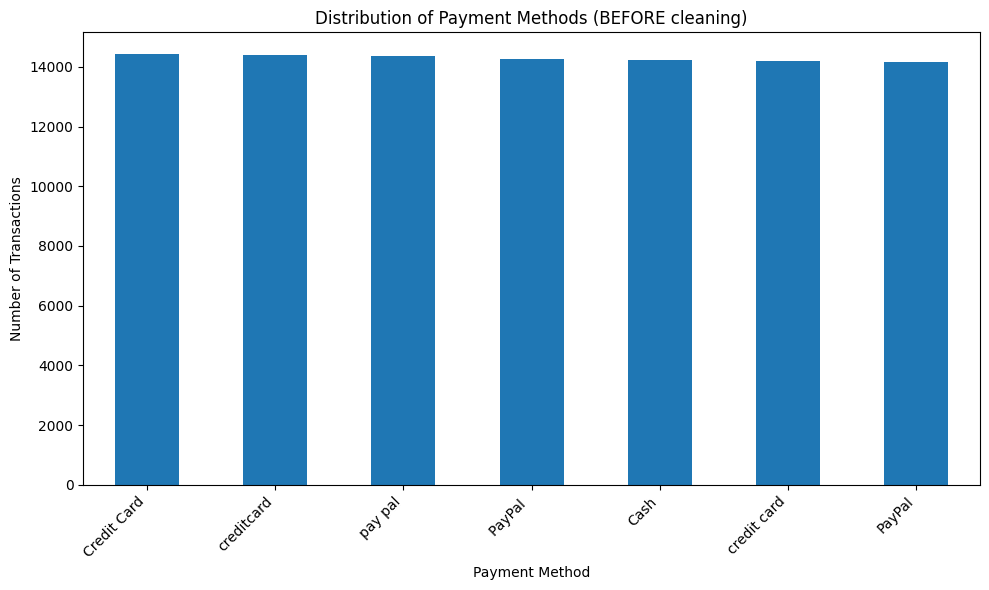

In [9]:
# Visualize the distribution BEFORE cleaning to see how fragmented the values are
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Payment Methods (BEFORE cleaning)')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Clean the Payment_Method column
df['Payment_Method'] = df['Payment_Method'].str.strip()        # remove surrounding whitespace
df['Payment_Method'] = df['Payment_Method'].str.lower()        # unify case
df['Payment_Method'] = df['Payment_Method'].replace({          # fix known variants
    'creditcard': 'credit card',
    'pay pal': 'paypal'
})
df['Payment_Method'] = df['Payment_Method'].str.title()        # 'credit card' → 'Credit Card'

print('Unique values after cleaning:', df['Payment_Method'].unique())

Unique values after cleaning: ['Paypal' 'Credit Card' 'Cash']


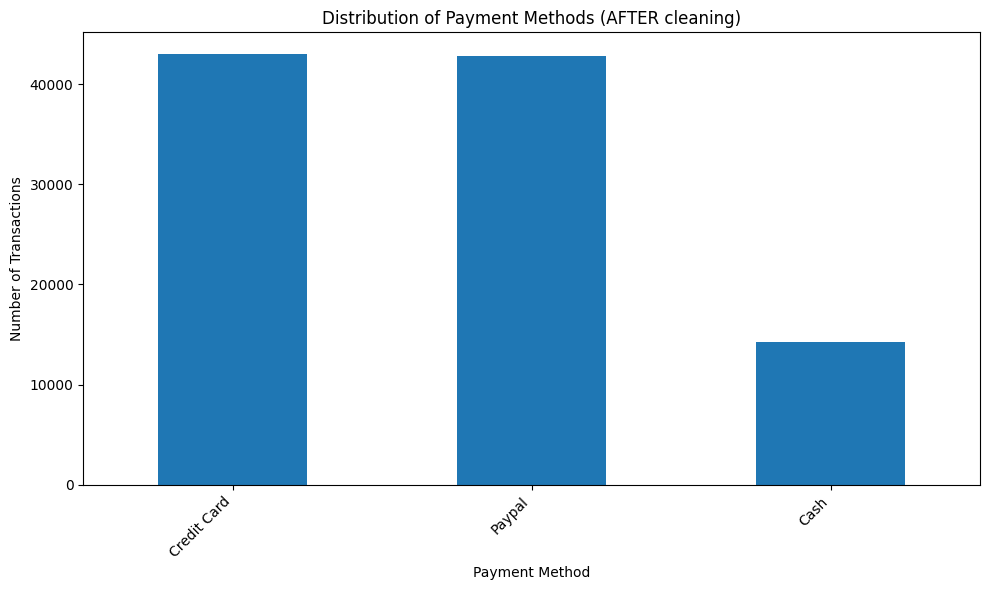

In [11]:
# Visualize AFTER cleaning — should now show exactly 3-4 clean categories
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Payment Methods (AFTER cleaning)')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📝 Takeaway
Always normalize text columns with `.str.strip().str.lower()` before doing any comparison or grouping. Then use `.replace()` to merge known variants into a single canonical label.

---
## Step 2 — Clean `Product_Name`

### Problem
Product names are **truncated** — it looks like a data entry field had a character limit
applied inconsistently: `'Lap'`, `'Lapto'`, `'Lapt'` all refer to `'Laptop'`.

This is harder to fix programmatically because there is no simple string rule.
We need a **manual mapping dictionary** that lists every known truncation and its correct form.

### Fix strategy
Build a dictionary `{dirty_value: clean_value}` and apply it with `.replace()`.

In [12]:
# Count occurrences of each unique Product_Name
# The long tail of rare values signals truncation artifacts
print(df['Product_Name'].value_counts())

Product_Name
Tablet            18444
Laptop            18264
Smartphone        18257
Headphones        18107
Coffee Machine    18085
Lapt                370
Table               352
La                  347
Tabl                346
Lapto               344
Ta                  344
T                   335
Lap                 334
Tab                 330
L                   321
Smartph             234
S                   223
H                   217
He                  212
Smart               206
Head                204
Smartp              203
Headpho             203
Headphon            203
Smartphon           203
Headphone           202
Headp               201
Headph              193
Hea                 192
Sma                 191
Sm                  189
Smartpho            181
Smar                180
Coffee Ma           157
Coffee Machi        150
Coffee Machin       150
Coffee              149
Coffee Mach         149
C                   141
Coffee M            140
Cof                 137
Cof

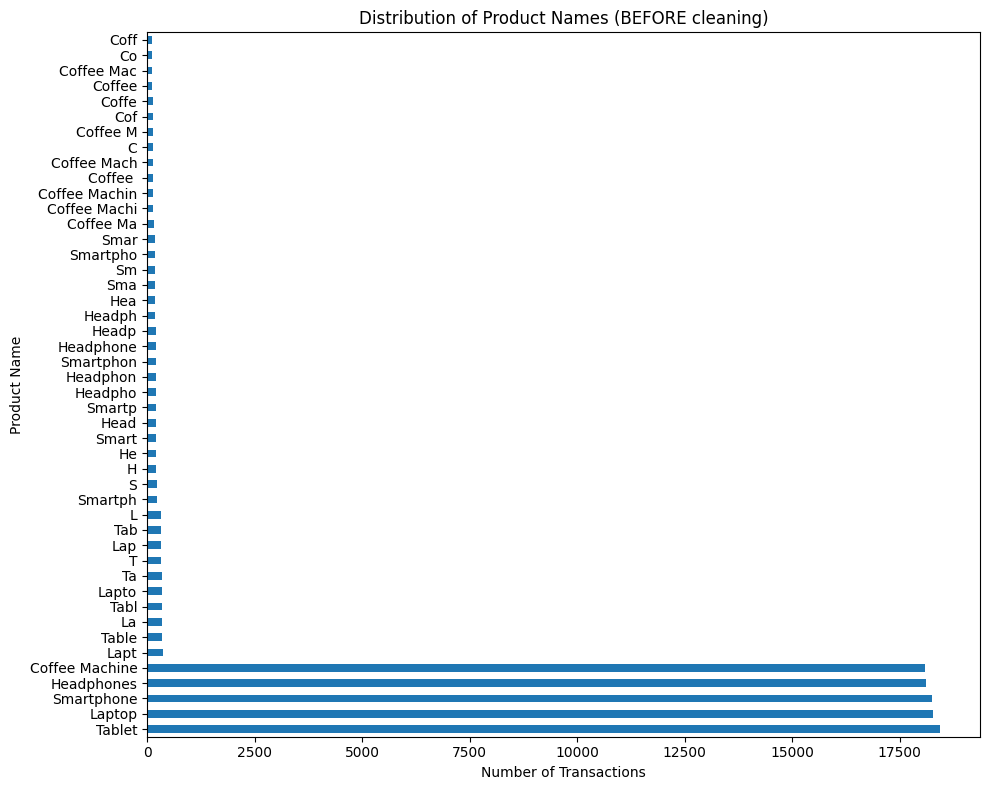

In [13]:
# Horizontal bar chart makes it easy to read long category names
product_name_counts = df['Product_Name'].value_counts()
product_name_counts.plot(kind='barh', figsize=(10, 8))
plt.title('Distribution of Product Names (BEFORE cleaning)')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

In [14]:
# Build a mapping from every known truncation to its correct full name
# This was identified by inspecting value_counts() above
product_name_mapping = {
    # Laptop variants
    'Lapt': 'Laptop', 'Lapto': 'Laptop', 'La': 'Laptop', 'Lap': 'Laptop', 'L': 'Laptop',
    
    # Tablet variants
    'Tabl': 'Tablet', 'Table': 'Tablet', 'Ta': 'Tablet', 'T': 'Tablet', 'Tab': 'Tablet',
   
    # Smartphone variants
    'Smartph': 'Smartphone', 'Smartp': 'Smartphone', 'Smar': 'Smartphone',
    'Sm': 'Smartphone', 'Smartpho': 'Smartphone', 'Smart': 'Smartphone',
    'S': 'Smartphone', 'Smartphon': 'Smartphone', 'Sma': 'Smartphone',
    
    # Headphones variants
    'Headp': 'Headphones', 'Headph': 'Headphones', 'Headpho': 'Headphones',
    'Headphon': 'Headphones', 'Hea': 'Headphones', 'He': 'Headphones',
    'H': 'Headphones', 'Head': 'Headphones', 'Headphone': 'Headphones',
    
    # Coffee Machine variants
    'Coffee Ma': 'Coffee Machine', 'Coffee Machi': 'Coffee Machine',
    'Coffee Machin': 'Coffee Machine', 'Coffee': 'Coffee Machine',
    'Coffee M': 'Coffee Machine', 'Cof': 'Coffee Machine', 'Coffe': 'Coffee Machine',
    'Coffee Mac': 'Coffee Machine', 'Co': 'Coffee Machine', 'Coff': 'Coffee Machine',
    'C': 'Coffee Machine', 'Coffee ': 'Coffee Machine', 'Coffee Mach': 'Coffee Machine'
}

df['Product_Name'] = df['Product_Name'].replace(product_name_mapping)
print('Unique product names after cleaning:', df['Product_Name'].unique())

Unique product names after cleaning: ['Headphones' 'Coffee Machine' 'Tablet' 'Smartphone' 'Laptop']


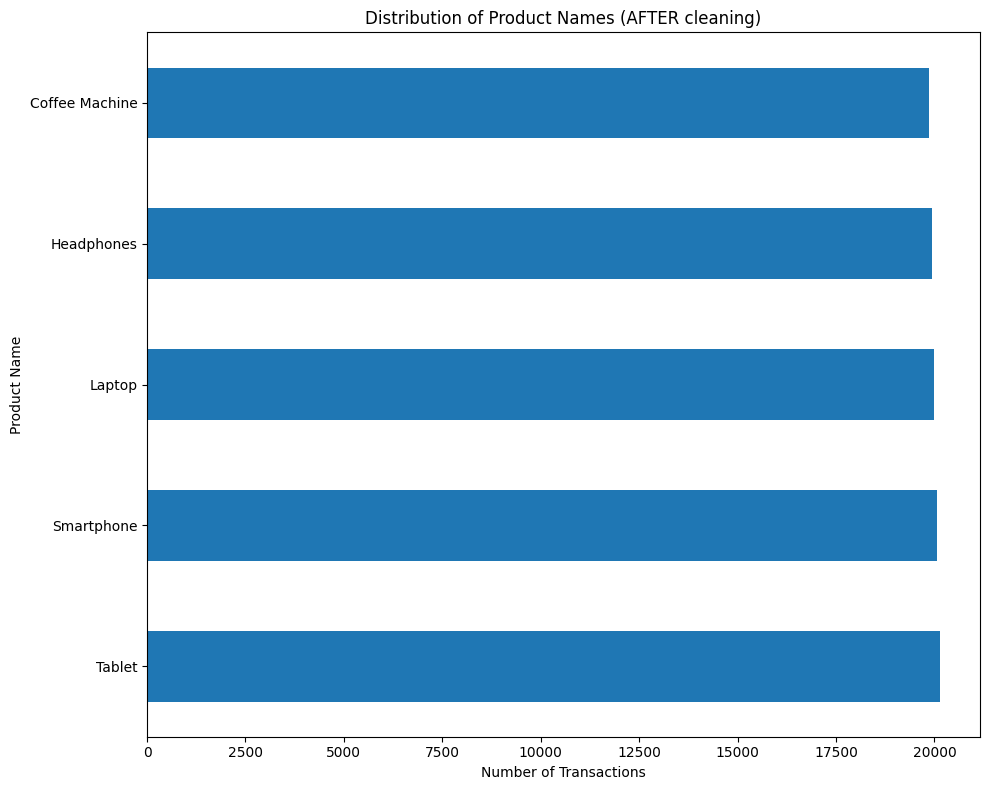

In [15]:
# AFTER cleaning — should now show exactly 5 clean product names
product_name_counts = df['Product_Name'].value_counts()
product_name_counts.plot(kind='barh', figsize=(10, 8))
plt.title('Distribution of Product Names (AFTER cleaning)')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

### 📝 Takeaway
When values are truncated, there is no magic function — you need domain knowledge to build a mapping. Always verify the result with `value_counts()` or a chart to confirm all variants were caught.

---
## Step 3 — Clean `Quantity`

### Problem
The `Quantity` column has **negative values** (min = -10). A transaction quantity can never
be negative — these are almost certainly data entry errors where the sign was flipped.
There are also extreme high values (max = 1000) that may be outliers.

### Fix strategy
1. Take the absolute value of all negatives → `.abs()`
2. Visualize the distribution (histogram, KDE, boxplot)
3. Detect outliers using the **Z-score** method and the **IQR** method

In [16]:
# Confirm the problem: negative minimum
print(f"Minimum Quantity before cleaning: {df['Quantity'].min()}")

Minimum Quantity before cleaning: -10.0


In [17]:
# Fix: convert all negatives to positive using absolute value
df['Quantity'] = df['Quantity'].abs()

print(f"Minimum Quantity after cleaning: {df['Quantity'].min()}")
print(f"Maximum Quantity after cleaning: {df['Quantity'].max()}")

Minimum Quantity after cleaning: 1.0
Maximum Quantity after cleaning: 1000.0


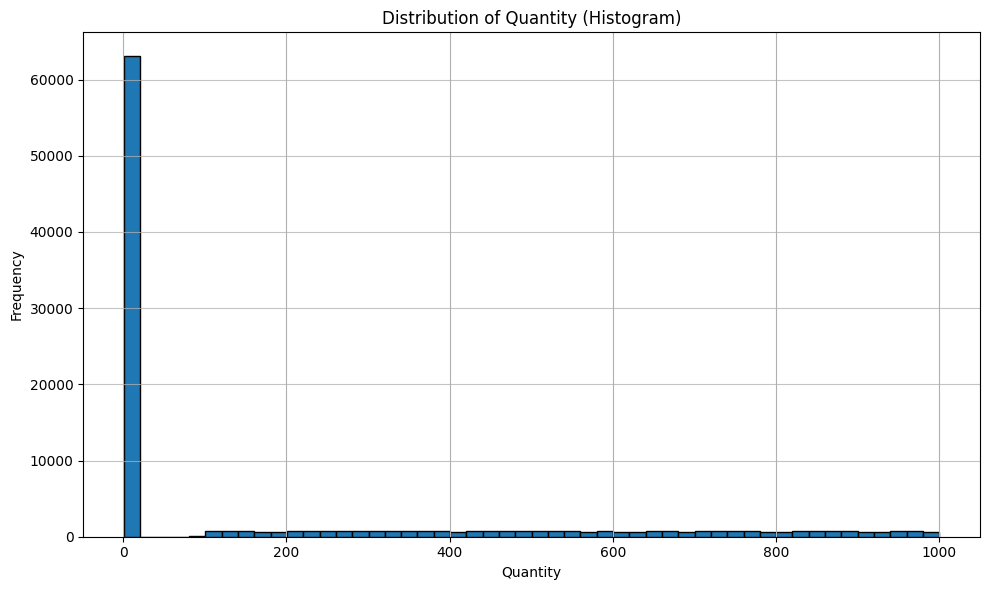

In [18]:
# Histogram: shows the overall shape of the distribution
# A bimodal or heavily skewed distribution hints at data quality issues
plt.figure(figsize=(10, 6))
df['Quantity'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Quantity (Histogram)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

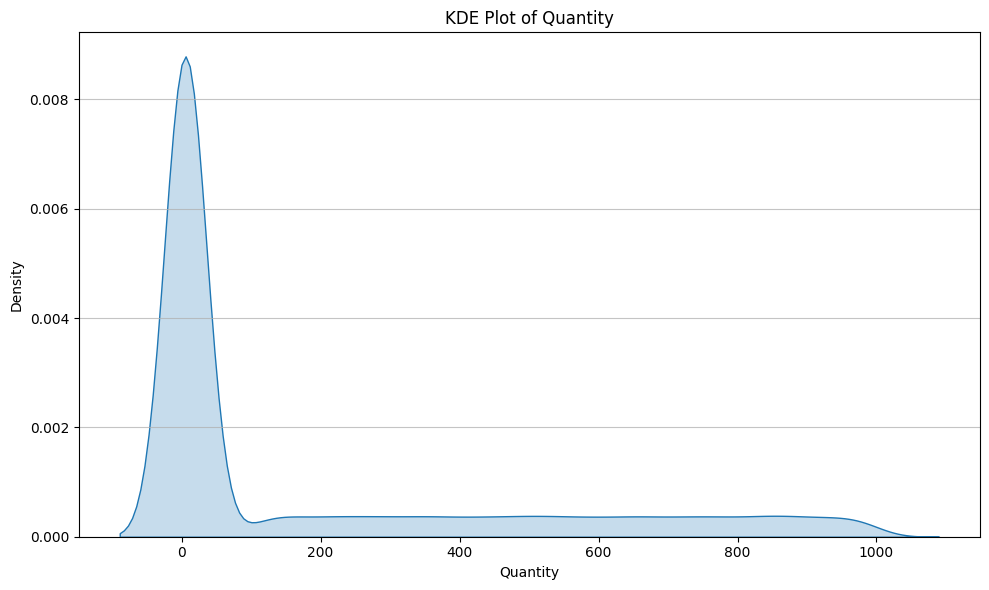

In [19]:
# KDE (Kernel Density Estimate): a smooth version of the histogram
# Useful for spotting multi-modal distributions or heavy tails
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Quantity'], fill=True)
plt.title('KDE Plot of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

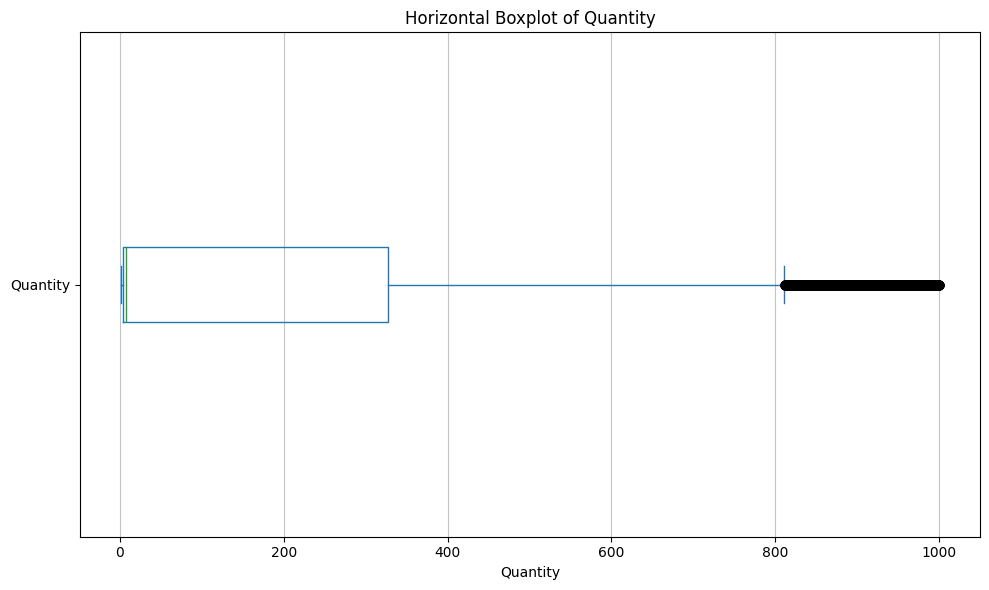

In [20]:
# Boxplot: the dots beyond the whiskers are statistical outliers
# The box spans Q1–Q3 (IQR), whiskers extend to 1.5×IQR
plt.figure(figsize=(10, 6))
df['Quantity'].plot(kind='box', vert=False)
plt.title('Horizontal Boxplot of Quantity')
plt.xlabel('Quantity')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

### Outlier Detection — Method 1: Z-Score

The **Z-score** measures how many standard deviations a value is from the mean.
A common threshold is `|Z| > 3` — values beyond that are statistical outliers.

```
Z = (x - mean) / std
```

**When to use**: works well when data is roughly normally distributed.

In [21]:
# Z-score outlier detection
df['Quantity_Zscore'] = np.abs(zscore(df['Quantity']))   # compute absolute Z-score per row

outlier_threshold = 3
outlier_rows = df[df['Quantity_Zscore'] > outlier_threshold]

print(f"Number of outliers (Z-score > {outlier_threshold}): {len(outlier_rows)}")
print(outlier_rows[['Transaction_ID', 'Customer_ID', 'Product_Name', 'Quantity', 'Quantity_Zscore']])

# Remove the temporary column — we only needed it for detection
df.drop(columns=['Quantity_Zscore'], inplace=True, errors='ignore')

Number of outliers (Z-score > 3): 0
Empty DataFrame
Columns: [Transaction_ID, Customer_ID, Product_Name, Quantity, Quantity_Zscore]
Index: []


### Outlier Detection — Method 2: IQR (Interquartile Range)

The **IQR method** is more robust than Z-score because it does not assume a normal distribution.
It defines outliers as values outside `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

```
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 × IQR
upper_bound = Q3 + 1.5 × IQR
```

**When to use**: preferred for skewed distributions or when you cannot assume normality.

In [22]:
# IQR outlier detection for Quantity
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_rows_iqr = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of outliers (IQR method): {len(outlier_rows_iqr)}")
print(outlier_rows_iqr[['Transaction_ID', 'Customer_ID', 'Product_Name', 'Quantity']])

Q1=4.0, Q3=327.0, IQR=323.0
Bounds: [-480.5, 811.5]
Number of outliers (IQR method): 6629
      Transaction_ID Customer_ID    Product_Name  Quantity
20             T0021       C1137  Coffee Machine     856.0
40             T0041       C1693          Laptop     865.0
45             T0046       C2797  Coffee Machine     825.0
51             T0052       C4029      Headphones     839.0
54             T0055       C2474  Coffee Machine     867.0
...              ...         ...             ...       ...
99876         T99877       C3496      Headphones     855.0
99897         T99898       C2043  Coffee Machine     962.0
99904         T99905        C667          Laptop     856.0
99928         T99929       C2897          Laptop     960.0
99993         T99994       C3391          Tablet     911.0

[6629 rows x 4 columns]


### 📝 Takeaway
Use **Z-score** when data is approximately normal. Use **IQR** when data is skewed or has heavy tails. In both cases, *detecting* outliers is separate from *deciding what to do* — you may drop them, cap them, or flag them for review depending on business context.

---
## Step 4 — Clean `Price`

### Problem
The `Price` column has three issues:
1. **Wrong dtype**: it is stored as `object` (string) — some entries have `$` symbols
2. **Negative values**: prices can't be negative (same data entry error as Quantity)
3. **Missing values**: some rows have no price at all

### Fix strategy
1. Convert to numeric, treating unparseable strings as `NaN` → `pd.to_numeric(errors='coerce')`
2. Fill `NaN` with `0` (or median — choose based on business rules)
3. Take absolute value → `.abs()`
4. Round to 2 decimal places → `.round(2)`

In [23]:
# Convert Price from string to float, coercing '$420.21' and other non-numeric formats to NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Fill NaN prices with 0 (assumption: unknown price = 0; alternatively use median)
df['Price'] = df['Price'].fillna(0)

print(f"Minimum Price before abs(): {df['Price'].min()}")

# Fix negative prices
df['Price'] = df['Price'].abs()

# Round to 2 decimal places for clean currency representation
df['Price'] = df['Price'].round(2)

print(f"Minimum Price after cleaning: {df['Price'].min()}")
print(f"Maximum Price after cleaning: {df['Price'].max()}")

Minimum Price before abs(): -999.9689029738316
Minimum Price after cleaning: 0.0
Maximum Price after cleaning: 999.99


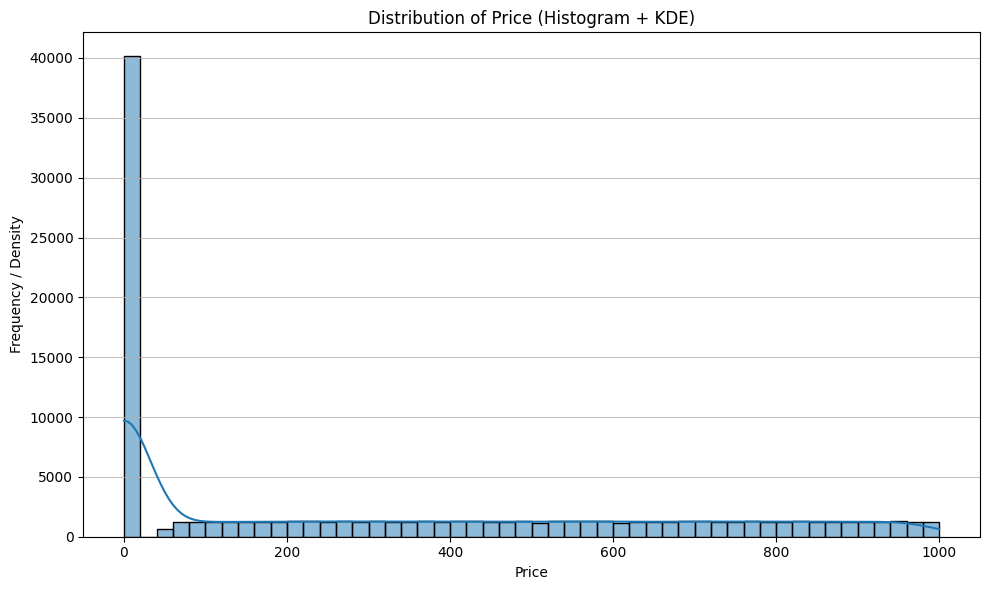

In [24]:
# Histogram overlaid with KDE — best of both worlds:
# bars show exact counts, KDE curve shows the smooth distribution shape
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=50, edgecolor='black')
plt.title('Distribution of Price (Histogram + KDE)')
plt.xlabel('Price')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

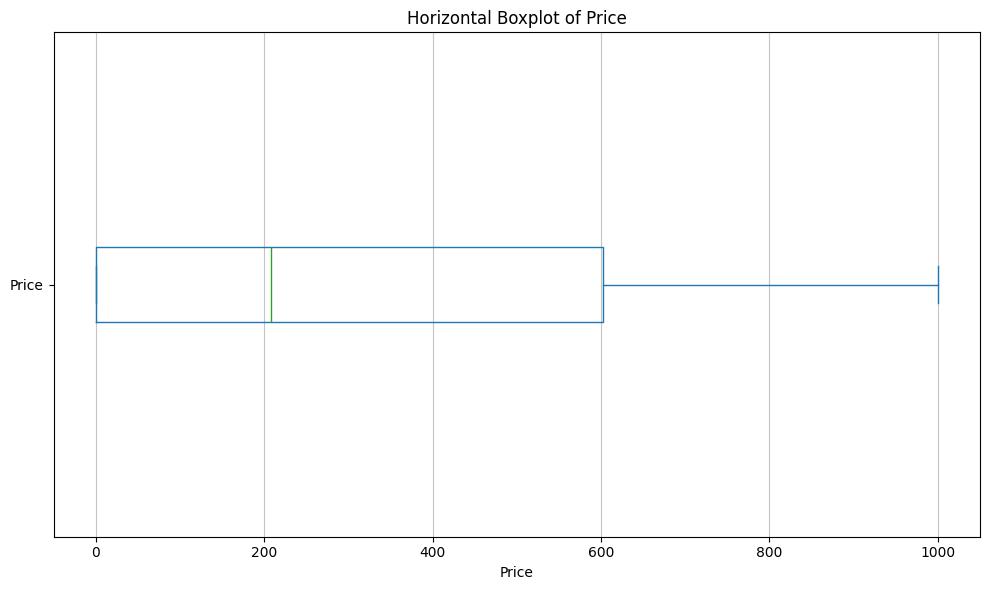

In [25]:
# Horizontal boxplot for Price — look for dots far from the box
plt.figure(figsize=(10, 6))
df['Price'].plot(kind='box', vert=False)
plt.title('Horizontal Boxplot of Price')
plt.xlabel('Price')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

In [26]:
# IQR outlier detection for Price (same method as Quantity above)
Q1_price = df['Price'].quantile(0.25)
Q3_price = df['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

outlier_rows_price = df[(df['Price'] < lower_bound_price) | (df['Price'] > upper_bound_price)]

print(f"Price bounds: [{lower_bound_price:.2f}, {upper_bound_price:.2f}]")
print(f"Number of Price outliers (IQR method): {len(outlier_rows_price)}")
print(outlier_rows_price[['Transaction_ID', 'Customer_ID', 'Product_Name', 'Price']])

Price bounds: [-903.16, 1505.28]
Number of Price outliers (IQR method): 0
Empty DataFrame
Columns: [Transaction_ID, Customer_ID, Product_Name, Price]
Index: []


### 📝 Takeaway
`pd.to_numeric(errors='coerce')` is the standard way to convert a messy string column to numbers — unparseable values become `NaN` rather than raising an error, so you can handle them explicitly afterwards.

---
## Step 5 — Clean `Transaction_Status`

### Problem
The status field has **case inconsistencies** and **abbreviations**:
- `'completed'`, `'Completed'`, `'complete'` → all mean Completed
- `'Failed'`, `'Pending'` → these appear correct but must be standardized
- Some rows are `NaN` — status unknown

### Fix strategy
1. Lowercase everything
2. Map `'complete'` → `'completed'`
3. Capitalize first letter for clean display

In [27]:
print('Before cleaning:')
print(df['Transaction_Status'].value_counts())

# Step 1: lowercase to unify 'Completed' and 'completed'
df['Transaction_Status'] = df['Transaction_Status'].str.lower()

# Step 2: map abbreviation 'complete' to the full form 'completed'
df['Transaction_Status'] = df['Transaction_Status'].replace({'complete': 'completed'})

# Step 3: capitalize first letter for consistent display (e.g., 'Completed')
df['Transaction_Status'] = df['Transaction_Status'].str.capitalize()

print('\nAfter cleaning:')
print(df['Transaction_Status'].value_counts())

Before cleaning:
Transaction_Status
Failed       16795
complete     16717
completed    16687
Pending      16595
Completed    16527
Name: count, dtype: int64

After cleaning:
Transaction_Status
Completed    49931
Failed       16795
Pending      16595
Name: count, dtype: int64


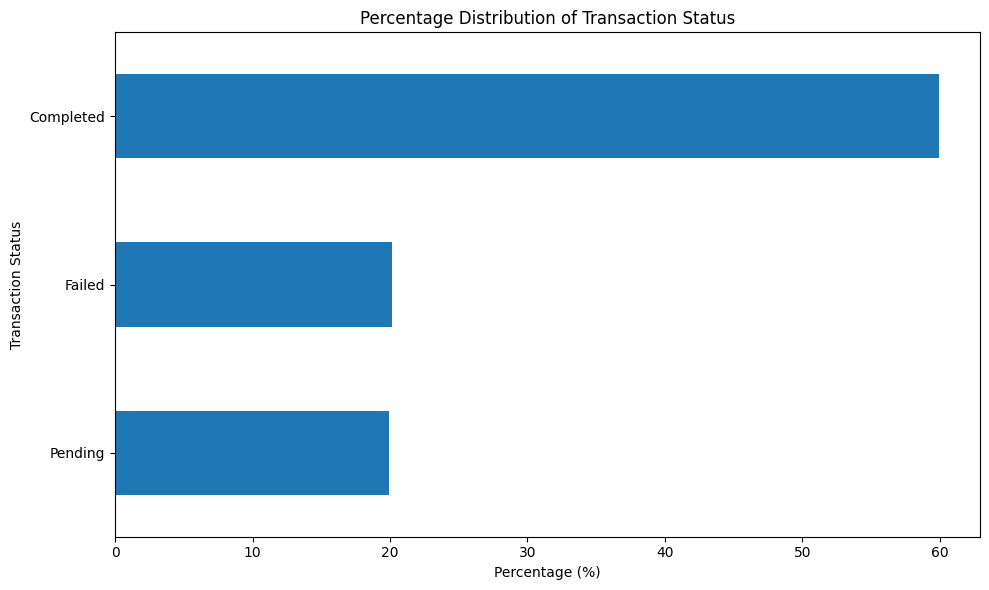

In [28]:
# Percentage distribution is more informative than raw counts
# when comparing relative proportions across categories
transaction_status_counts = df['Transaction_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
transaction_status_counts.plot(kind='barh')
plt.title('Percentage Distribution of Transaction Status')
plt.xlabel('Percentage (%)')
plt.ylabel('Transaction Status')
plt.gca().invert_yaxis()   # highest bar at the top
plt.tight_layout()
plt.show()

### 📝 Takeaway
Always use `normalize=True` in `value_counts()` when you care about proportions rather than raw counts. Using percentages makes it easy to compare distributions across datasets of different sizes.

---
## Step 6 — Handle Missing Values

### Why missing values matter
Most ML models and many pandas operations cannot handle `NaN` values.
You must decide for each column: **drop** rows with missing values, or **impute** (fill) them?

| Column | Strategy | Reason |
|---|---|---|
| `Transaction_Status` | Drop rows | Status is essential; guessing it would be misleading |
| `Transaction_ID` | Drop rows | Unique identifier — rows without it are unidentifiable |
| `Customer_ID` | Drop rows | Same as above |
| `Quantity` | Fill with median | Median is robust to outliers; better than dropping |


In [29]:
# Count missing values per column
print(df.isnull().sum())

Transaction_ID         5018
Transaction_Date       4880
Customer_ID            4878
Product_Name              0
Quantity               5019
Price                     0
Payment_Method            0
Transaction_Status    16679
dtype: int64


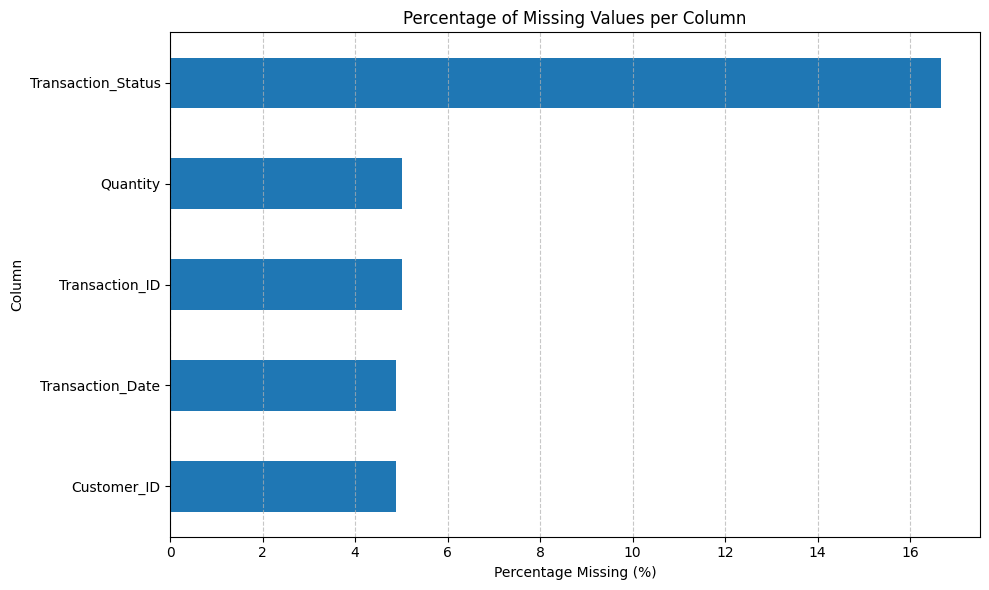

In [30]:
# Visualize missingness as a percentage — makes it easy to prioritize which columns to fix first
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if not missing_percentage.empty:
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='barh')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Column')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [31]:
# Drop rows where Transaction_Status is NaN — we cannot infer what the status should be
df.dropna(subset=['Transaction_Status'], inplace=True)

print(f"Remaining missing in Transaction_Status: {df['Transaction_Status'].isnull().sum()}")

Remaining missing in Transaction_Status: 0


In [32]:
# Check remaining missingness across all columns
print(df.isnull().sum())

Transaction_ID        4157
Transaction_Date      4064
Customer_ID           4041
Product_Name             0
Quantity              4200
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### Handling Missing `Transaction_ID` and `Customer_ID`

These are **primary keys** — rows without them cannot be linked to any customer or transaction record.
Imputing these would be meaningless, so we drop those rows.

In [33]:
# Drop rows missing the primary key columns — they are not usable records
df.dropna(subset=['Transaction_ID'], inplace=True)
df.dropna(subset=['Customer_ID'], inplace=True)

print('Missing values after dropping incomplete IDs:')
print(df.isnull().sum())

Missing values after dropping incomplete IDs:
Transaction_ID           0
Transaction_Date      3694
Customer_ID              0
Product_Name             0
Quantity              3757
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### Imputing Missing `Quantity` with the Median

For `Quantity`, dropping rows would lose valid transaction data. Instead, we **impute**
with the **median** — it is more robust than the mean because it is not pulled by outliers.

In [34]:
# Impute missing Quantity values with the median
median_quantity = df['Quantity'].median()
df['Quantity'] = df['Quantity'].fillna(median_quantity)

print(f"Median used for imputation: {median_quantity}")
print(f"Remaining missing in Quantity: {df['Quantity'].isnull().sum()}")
print('\nFinal missing values summary:')
print(df.isnull().sum())

Median used for imputation: 8.0
Remaining missing in Quantity: 0

Final missing values summary:
Transaction_ID           0
Transaction_Date      3694
Customer_ID              0
Product_Name             0
Quantity                 0
Price                    0
Payment_Method           0
Transaction_Status       0
dtype: int64


### 📝 Takeaway
The decision to **drop vs impute** depends on: (1) how much data you can afford to lose, (2) whether imputing would introduce misleading patterns. For identifiers and status fields, drop. For numeric measurements, impute with median (skewed data) or mean (normal data).

---
## Step 7 — Clean `Transaction_Date`

### Problem
The date column is stored as a **string**, and some entries contain **impossible dates**
such as `'2025-02-30'` (February has at most 29 days). These cannot be converted to a
real datetime object.

### Fix strategy
1. Use `pd.to_datetime(errors='coerce')` — invalid dates become `NaT` (Not a Time)
2. Visualize how many rows are affected
3. Drop rows with `NaT` dates — we cannot guess the correct date

In [35]:
# Convert the string column to datetime; errors='coerce' turns invalid dates into NaT
# instead of raising an exception
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

print(f"Rows with invalid/missing dates (NaT): {df['Transaction_Date'].isnull().sum()}")
print('\nMissing values summary after date parsing:')
print(df.isnull().sum())

Rows with invalid/missing dates (NaT): 51375

Missing values summary after date parsing:
Transaction_ID            0
Transaction_Date      51375
Customer_ID               0
Product_Name              0
Quantity                  0
Price                     0
Payment_Method            0
Transaction_Status        0
dtype: int64


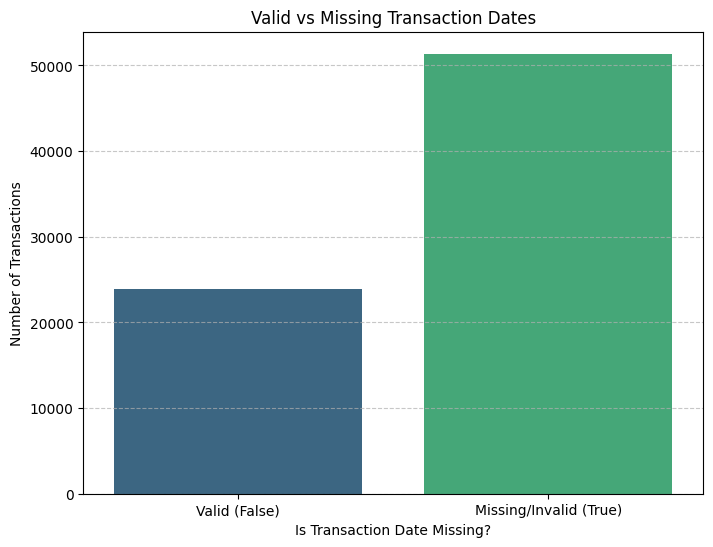

In [36]:
# Create a boolean flag column to visualize valid vs missing dates
df['is_date_missing'] = df['Transaction_Date'].isnull()

plt.figure(figsize=(8, 6))
sns.countplot(
    x='is_date_missing', data=df,
    palette='viridis', hue='is_date_missing', legend=False
)
plt.title('Valid vs Missing Transaction Dates')
plt.xlabel('Is Transaction Date Missing?')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Valid (False)', 'Missing/Invalid (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Drop the temporary helper column
df.drop(columns=['is_date_missing'], inplace=True)

In [37]:
# Drop rows with invalid dates — we cannot reconstruct the correct date
df.dropna(subset=['Transaction_Date'], inplace=True)

print('Missing values after dropping invalid dates:')
print(df.isnull().sum())

Missing values after dropping invalid dates:
Transaction_ID        0
Transaction_Date      0
Customer_ID           0
Product_Name          0
Quantity              0
Price                 0
Payment_Method        0
Transaction_Status    0
dtype: int64


In [38]:
# Confirm the dataset looks correct after all cleaning so far
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
1,T0002,2020-02-10,C3156,Coffee Machine,469.0,445.34,Credit Card,Pending
3,T0004,2020-08-17,C3009,Tablet,7.0,868.61,Paypal,Pending
5,T0006,2021-10-26,C4241,Smartphone,598.0,0.00,Paypal,Completed
12,T0013,2020-03-18,C1692,Smartphone,564.0,0.00,Cash,Completed
13,T0014,2020-06-19,C2992,Coffee Machine,696.0,905.51,Credit Card,Failed


### 📝 Takeaway
`errors='coerce'` is the key parameter in `pd.to_datetime()`. Without it, a single bad date
crashes the entire conversion. With it, bad values become `NaT` which you can then inspect and handle.

---
## Step 8 — Handle Duplicate Rows

### Problem
Duplicate rows can arise from data pipeline errors, double-submissions, or merging datasets.
They inflate counts and skew aggregations.

### Fix strategy
1. Count duplicates with `.duplicated().sum()`
2. Inspect them
3. Remove them with `.drop_duplicates()` — keeps the first occurrence by default

In [39]:
# Count exact duplicate rows (all columns must match)
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 239


In [40]:
# Inspect the actual duplicate records before removing them
duplicates = df.duplicated()
df[duplicates]

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
5455,T5456,2022-11-01,C1548,Tablet,530.0,706.48,Paypal,Pending
5938,T5939,2023-04-14,C2656,Laptop,6.0,0.00,Cash,Completed
8125,T8126,2021-05-25,C2396,Smartphone,4.0,335.99,Paypal,Completed
9123,T7493,2020-03-29,C680,Smartphone,8.0,0.00,Paypal,Completed
15384,T5049,2022-05-23,C1866,Headphones,330.0,442.89,Credit Card,Pending
...,...,...,...,...,...,...,...,...
97961,T97962,2022-09-17,C4247,Laptop,2.0,0.00,Credit Card,Pending
98179,T98180,2020-11-13,C888,Coffee Machine,726.0,466.85,Paypal,Pending
98478,T56209,2022-01-17,C1247,Smartphone,601.0,748.89,Paypal,Failed
98627,T98628,2023-03-31,C2782,Laptop,123.0,0.00,Paypal,Pending


In [41]:
# Remove duplicates — keep='first' retains the first occurrence of each duplicate set
df = df.drop_duplicates()
print(f"Total duplicate rows after removal: {df.duplicated().sum()}")

Total duplicate rows after removal: 0


### 📝 Takeaway
Always check for duplicates before analysis. `drop_duplicates(keep='first')` is safe for most cases, but if you have a natural key (like `Transaction_ID`), prefer `drop_duplicates(subset=['Transaction_ID'])` to be more precise.

---
## Step 9 — Optimize Data Types

### Why data types matter
Pandas uses `int64` and `float64` by default — these use 8 bytes per value.
If your values fit in a smaller type, you can cut memory usage dramatically:

| Type | Bytes | Range |
|---|---|---|
| `int64` (default) | 8 | ±9.2 × 10¹⁸ |
| `int16` | 2 | −32,768 to 32,767 |
| `float64` (default) | 8 | ±1.8 × 10³⁰⁸ |
| `float32` | 4 | ±3.4 × 10³⁸ (6-7 decimal digits) |
| `category` | variable | any fixed set of strings |

For a 100,000-row dataset this is modest, but at 10M+ rows these savings become critical.

In [42]:
# Review current dtypes and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23706 entries, 1 to 99998
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  float64       
 5   Price               23706 non-null  float64       
 6   Payment_Method      23706 non-null  object        
 7   Transaction_Status  23706 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 1.6+ MB


In [43]:
# Check min/max to choose the smallest safe type
df.describe()

,Transaction_Date,Quantity,Price
count,23706,23706.000000,23706.000000
mean,2022-07-23 19:58:25.239179776,179.850038,314.425607
min,2020-01-01 00:00:00,1.000000,0.000000
25%,2021-04-17 00:00:00,5.000000,0.000000
50%,2022-07-26 12:00:00,8.000000,206.940000
75%,2023-10-29 00:00:00,297.000000,604.350000
max,2025-02-01 00:00:00,1000.000000,999.960000
std,NaN,293.132091,333.407530


In [44]:
# Quantity range: 1–1000 → fits in int16 (max 32,767)
# Saves 75% memory vs int64 (2 bytes instead of 8)
df['Quantity'] = df['Quantity'].astype('int16')

print('Data types after optimizing Quantity:')
df.info()

Data types after optimizing Quantity:
<class 'pandas.core.frame.DataFrame'>
Index: 23706 entries, 1 to 99998
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  int16         
 5   Price               23706 non-null  float64       
 6   Payment_Method      23706 non-null  object        
 7   Transaction_Status  23706 non-null  object        
dtypes: datetime64[ns](1), float64(1), int16(1), object(5)
memory usage: 1.5+ MB


In [45]:
# Price range: 0–999.96 → fits in float32 (preserves 6-7 decimal digits)
# Saves 50% memory vs float64 (4 bytes instead of 8)
df['Price'] = df['Price'].astype('float32')

print('Data types after optimizing Price:')
df.info()

Data types after optimizing Price:
<class 'pandas.core.frame.DataFrame'>
Index: 23706 entries, 1 to 99998
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  int16         
 5   Price               23706 non-null  float32       
 6   Payment_Method      23706 non-null  object        
 7   Transaction_Status  23706 non-null  object        
dtypes: datetime64[ns](1), float32(1), int16(1), object(5)
memory usage: 1.4+ MB


In [46]:
# Reset index after all the row drops so it runs 0, 1, 2, ... sequentially
df = df.reset_index(drop=True)

# Convert string columns with a small fixed set of values to 'category' dtype
# This stores each unique string only once and uses an integer code per row
df['Payment_Method'] = df['Payment_Method'].astype('category')
df['Transaction_Status'] = df['Transaction_Status'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      23706 non-null  object        
 1   Transaction_Date    23706 non-null  datetime64[ns]
 2   Customer_ID         23706 non-null  object        
 3   Product_Name        23706 non-null  object        
 4   Quantity            23706 non-null  int16         
 5   Price               23706 non-null  float32       
 6   Payment_Method      23706 non-null  category      
 7   Transaction_Status  23706 non-null  category      
dtypes: category(2), datetime64[ns](1), float32(1), int16(1), object(3)
memory usage: 926.4+ KB


In [47]:
# Drop the identifier columns — they are not useful as features for analysis or ML
df = df.drop(columns=['Transaction_ID', 'Customer_ID'])

print('Final DataFrame info:')
df.info()

Final DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_Date    23706 non-null  datetime64[ns]
 1   Product_Name        23706 non-null  object        
 2   Quantity            23706 non-null  int16         
 3   Price               23706 non-null  float32       
 4   Payment_Method      23706 non-null  category      
 5   Transaction_Status  23706 non-null  category      
dtypes: category(2), datetime64[ns](1), float32(1), int16(1), object(1)
memory usage: 556.0+ KB


### 📝 Takeaway
After cleaning, always review dtypes with `.info()`. Use `int16`/`int32` for integers with a known range, `float32` for prices/scores, and `category` for string columns with a small fixed vocabulary. This can reduce memory usage by 50–80%.

---
## Step 10 — Save the Cleaned Dataset

### Why Parquet instead of CSV?

| Feature | CSV | Parquet |
|---|---|---|
| Dtype preservation | ❌ Everything becomes string on reload | ✅ Exact types saved |
| File size | Larger (plain text) | Smaller (columnar + compressed) |
| Read speed | Slower | Much faster for large files |
| Category support | ❌ Lost on reload | ✅ Preserved |

After all the work we did to set correct dtypes, saving as CSV would lose them all.

In [48]:
# Save cleaned DataFrame to Parquet — preserves all dtypes including category and datetime
output_path = 'cleaned_financial_transactions.parquet'
df.to_parquet(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: cleaned_financial_transactions.parquet


In [49]:
# Reload and verify — dtypes should match exactly what we saved
df_loaded = pd.read_parquet(output_path)
print(f"Loaded from: {output_path}")

Loaded from: cleaned_financial_transactions.parquet


In [50]:
# Confirm dtypes survived the save/load cycle
print('Info of loaded DataFrame:')
df_loaded.info()

Info of loaded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23706 entries, 0 to 23705
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_Date    23706 non-null  datetime64[ns]
 1   Product_Name        23706 non-null  object        
 2   Quantity            23706 non-null  int16         
 3   Price               23706 non-null  float32       
 4   Payment_Method      23706 non-null  category      
 5   Transaction_Status  23706 non-null  category      
dtypes: category(2), datetime64[ns](1), float32(1), int16(1), object(1)
memory usage: 556.0+ KB


In [51]:
# Sanity check: first 5 rows of the fully cleaned dataset
print('First 5 rows of the cleaned DataFrame:')
display(df_loaded.head())

First 5 rows of the cleaned DataFrame:


,Transaction_Date,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,2020-02-10,Coffee Machine,469,445.339996,Credit Card,Pending
1,2020-08-17,Tablet,7,868.609985,Paypal,Pending
2,2021-10-26,Smartphone,598,0.000000,Paypal,Completed
3,2020-03-18,Smartphone,564,0.000000,Cash,Completed
4,2020-06-19,Coffee Machine,696,905.510010,Credit Card,Failed


---
## Summary — What We Did

| Step | Column | Problem | Solution | Key Function |
|---|---|---|---|---|
| 1 | `Payment_Method` | Inconsistent labels | Normalize + map | `.str.strip().str.lower()`, `.replace()` |
| 2 | `Product_Name` | Truncated names | Manual mapping dict | `.replace({...})` |
| 3 | `Quantity` | Negative values, outliers | Absolute value + detect outliers | `.abs()`, Z-score, IQR |
| 4 | `Price` | String type, negatives, missing | Convert → fill → abs → round | `pd.to_numeric()`, `.fillna()`, `.abs()`, `.round()` |
| 5 | `Transaction_Status` | Mixed case, abbreviations | Normalize + capitalize | `.str.lower()`, `.replace()`, `.str.capitalize()` |
| 6 | All | Missing values | Drop (IDs/Status) or impute (Quantity) | `.dropna()`, `.fillna()` |
| 7 | `Transaction_Date` | Invalid dates (Feb 30) | Parse with coerce → drop NaT | `pd.to_datetime(errors='coerce')` |
| 8 | All rows | Duplicates | Remove exact duplicates | `.drop_duplicates()` |
| 9 | All columns | Default dtypes wasteful | Downcast numeric + category | `.astype('int16')`, `.astype('float32')`, `.astype('category')` |
| 10 | — | Save with types intact | Export to Parquet | `.to_parquet()` |

### General data cleaning checklist
- [ ] Inspect the data first — `head()`, `describe()`, `info()`, `value_counts()`
- [ ] Fix string columns — strip, lowercase, map variants
- [ ] Fix numeric columns — correct wrong signs, convert types, handle missing
- [ ] Fix date columns — parse with `errors='coerce'`, drop unparseable rows
- [ ] Handle missing values — decide drop vs impute per column
- [ ] Remove duplicates
- [ ] Optimize dtypes to save memory
- [ ] Verify with plots and `.info()` after each step
- [ ] Save in a format that preserves dtypes (Parquet)
